In [1]:
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from scipy.sparse import hstack

                               TASK 1
                    TF-IDF Feature Extraction + Comparison


In [ ]:
# 1) LOAD DATA
disease_df = pd.read_csv("disease_features.csv")     
one_hot_df = pd.read_csv("encoded_output2.csv")      

print("Disease DataFrame HEAD:")
print(disease_df.head(), "\n")
print("One-hot Encoded DataFrame HEAD:")
print(one_hot_df.head(), "\n")

# 2) PARSE lists from string
def parse_string_list(str_list):
    try:
        return ast.literal_eval(str_list)
    except:
        return []

text_columns = ["Risk Factors", "Symptoms", "Signs"]
for col in text_columns:
    disease_df[col] = disease_df[col].apply(parse_string_list)
    # 3) Convert each to single string
    disease_df[col] = disease_df[col].apply(lambda x: " ".join(x))

# 4) TF-IDF for each column
tfidf_vectors = []
vectorizers = {}
for col in text_columns:
    vectorizer = TfidfVectorizer()
    mat = vectorizer.fit_transform(disease_df[col])
    tfidf_vectors.append(mat)
    vectorizers[col] = vectorizer

# 5) COMBINE TF-IDF
from scipy.sparse import hstack
tfidf_feature_matrix = hstack(tfidf_vectors)
print("TF-IDF Combined shape:", tfidf_feature_matrix.shape)

# 6) COMPARE to one-hot
tfidf_nnz = tfidf_feature_matrix.nnz
one_hot_data = one_hot_df.iloc[:,1:].values  # ignoring 1st col if it's label
one_hot_nnz = one_hot_data.sum()

tfidf_sparsity = 1 - (tfidf_nnz / (tfidf_feature_matrix.shape[0]*tfidf_feature_matrix.shape[1]))
one_hot_sparsity = 1 - (one_hot_nnz / (one_hot_data.shape[0]*one_hot_data.shape[1]))

print(f"TF-IDF sparsity: {tfidf_sparsity:.4f}")
print(f"One-hot sparsity: {one_hot_sparsity:.4f}")

# unique features
total_tfidf_features = sum(len(vectorizers[c].vocabulary_) for c in text_columns)
one_hot_features = one_hot_data.shape[1]
print(f"Total TF-IDF features: {total_tfidf_features}")
print(f"Total one-hot features: {one_hot_features}")

Disease DataFrame HEAD:
                   Disease                                       Risk Factors  \
0  Acute Coronary Syndrome  ['Hyperlipidemia', 'hypertension', 'smoking', ...   
1    Adrenal Insufficiency  ['Autoimmune diseases', 'Genetic predispositio...   
2                Alzheimer  ['Age', 'genetic factors', 'gender', 'cardiova...   
3        Aortic Dissection  ['Hypertension', 'Atherosclerosis', 'Family hi...   
4                   Asthma  ['Allergies', 'family history of asthma or all...   

                                            Symptoms  \
0  ['Chest pain', 'sweating', 'nausea', 'vomiting...   
1  ['Fatigue', 'Muscle weakness', 'Weight loss', ...   
2  ['Cognitive decline, including memory loss and...   
3  ['Intense chest or upper back pain', 'Sudden s...   
4  ['Recurrent episodes of wheezing', 'breathless...   

                                               Signs  \
0                                                 []   
1  ['Hyperpigmentation (especially in cr

                               TASK 2
                        Dimensionality Reduction



Explained variance ratio (TF-IDF, PCA): [0.06583913 0.05897588]
Explained variance ratio (One-hot, PCA): [0.10538866 0.09170854]

Explained variance ratio (TF-IDF, SVD): [0.00886477 0.06571728]
Explained variance ratio (One-hot, SVD): [0.02247731 0.09194331]


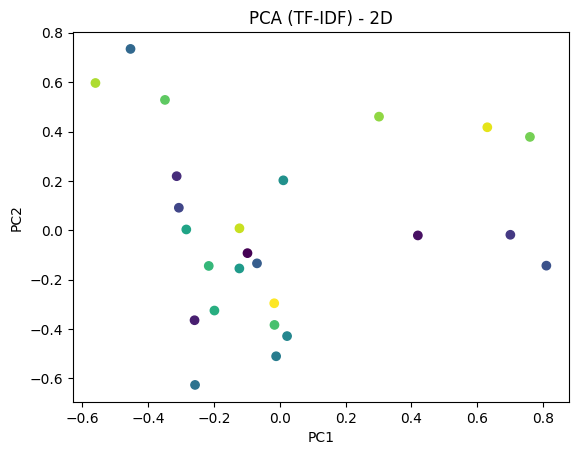

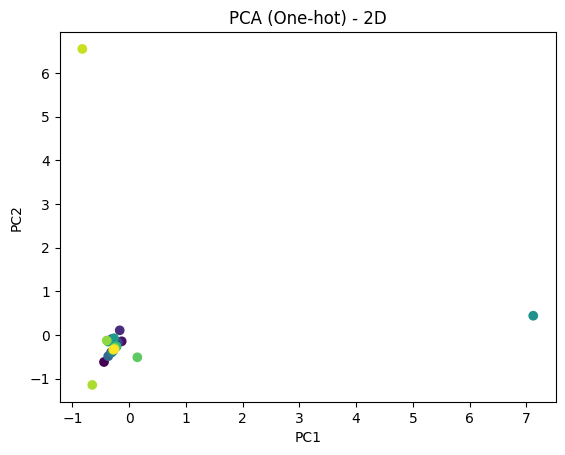

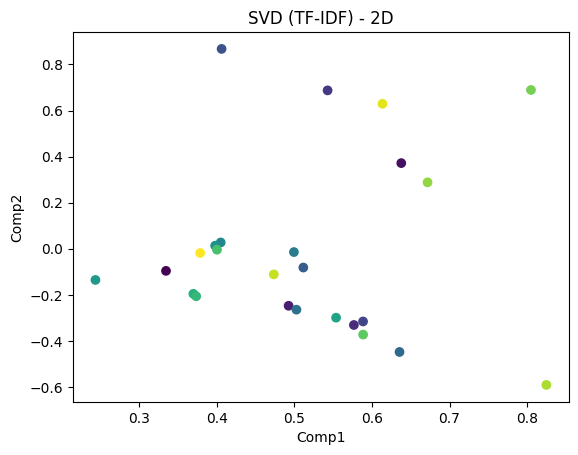

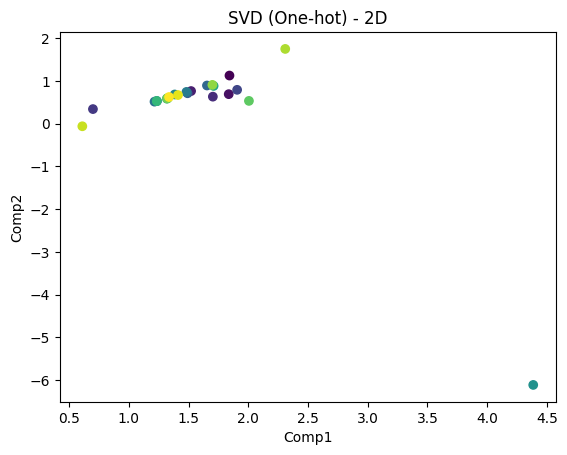

In [ ]:
if "Disease" in disease_df.columns:
    disease_labels = disease_df["Disease"].values
else:
    disease_labels = disease_df["Subtype"].values

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(disease_labels)

NUM_COMPONENTS = 2  # for 2D

tfidf_array = tfidf_feature_matrix.toarray()
one_hot_array = one_hot_data

# PCA
pca_tfidf = PCA(n_components=NUM_COMPONENTS, random_state=42)
tfidf_pca_2d = pca_tfidf.fit_transform(tfidf_array)

pca_onehot = PCA(n_components=NUM_COMPONENTS, random_state=42)
one_hot_pca_2d = pca_onehot.fit_transform(one_hot_array)

print("\nExplained variance ratio (TF-IDF, PCA):", pca_tfidf.explained_variance_ratio_)
print("Explained variance ratio (One-hot, PCA):", pca_onehot.explained_variance_ratio_)

# SVD
svd_tfidf = TruncatedSVD(n_components=NUM_COMPONENTS, random_state=42)
tfidf_svd_2d = svd_tfidf.fit_transform(tfidf_feature_matrix)

svd_onehot = TruncatedSVD(n_components=NUM_COMPONENTS, random_state=42)
one_hot_svd_2d = svd_onehot.fit_transform(one_hot_array)

print("\nExplained variance ratio (TF-IDF, SVD):", svd_tfidf.explained_variance_ratio_)
print("Explained variance ratio (One-hot, SVD):", svd_onehot.explained_variance_ratio_)

# PLOT
plt.figure()
plt.scatter(tfidf_pca_2d[:,0], tfidf_pca_2d[:,1], c=encoded_labels)
plt.title("PCA (TF-IDF) - 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure()
plt.scatter(one_hot_pca_2d[:,0], one_hot_pca_2d[:,1], c=encoded_labels)
plt.title("PCA (One-hot) - 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure()
plt.scatter(tfidf_svd_2d[:,0], tfidf_svd_2d[:,1], c=encoded_labels)
plt.title("SVD (TF-IDF) - 2D")
plt.xlabel("Comp1")
plt.ylabel("Comp2")
plt.show()

plt.figure()
plt.scatter(one_hot_svd_2d[:,0], one_hot_svd_2d[:,1], c=encoded_labels)
plt.title("SVD (One-hot) - 2D")
plt.xlabel("Comp1")
plt.ylabel("Comp2")
plt.show()

                               TASK 3
     KNN (k=3,5,7, Euclidean/Manhattan/Cosine) + Logistic Regression (5-fold)


In [ ]:
from sklearn.model_selection import StratifiedKFold

def cross_validate_knn(X, y, k_values=[3,5,7], metrics=["euclidean","manhattan","cosine"], folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    results = []
    for k in k_values:
        for dist in metrics:
            accs, precs, recs, f1s = [], [], [], []
            for train_ix, test_ix in skf.split(X,y):
                X_tr, X_te = X[train_ix], X[test_ix]
                y_tr, y_te = y[train_ix], y[test_ix]
                knn = KNeighborsClassifier(n_neighbors=k, metric=dist)
                knn.fit(X_tr, y_tr)
                y_pred = knn.predict(X_te)
                accs.append(accuracy_score(y_te, y_pred))
                precs.append(precision_score(y_te, y_pred, average='macro', zero_division=0))
                recs.append(recall_score(y_te, y_pred, average='macro', zero_division=0))
                f1s.append(f1_score(y_te, y_pred, average='macro', zero_division=0))
            results.append({
                "K": k,
                "Metric": dist,
                "Accuracy":  np.mean(accs),
                "Precision": np.mean(precs),
                "Recall":    np.mean(recs),
                "F1-score":  np.mean(f1s)
            })
    return pd.DataFrame(results)

def cross_validate_logreg(X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    accs, f1s = [], []
    for train_ix, test_ix in skf.split(X,y):
        X_tr, X_te = X[train_ix], X[test_ix]
        y_tr, y_te = y[train_ix], y[test_ix]
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        accs.append(accuracy_score(y_te, y_pred))
        f1s.append(f1_score(y_te, y_pred, average='macro', zero_division=0))
    return np.mean(accs), np.mean(f1s)

# CHECK if min class >= 5
unique_labs, counts = np.unique(encoded_labels, return_counts=True)
min_count = counts.min()

if min_count < 5:
    print("\nWARNING: Some class has <5 samples. 5-fold CV is not possible with StratifiedKFold.")
    print("Falling back to a non-stratified single train_test_split (no guaranteed class balancing).")

    # We'll do a single train/test without stratify
    X_tfidf = tfidf_array
    X_onehot = one_hot_array
    y = encoded_labels

    X_train_tf, X_test_tf, y_train, y_test = train_test_split(
        X_tfidf, y, test_size=0.3, random_state=42  # NO stratify
    )
    # KNN example on TF-IDF
    knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
    knn.fit(X_train_tf, y_train)
    y_pred = knn.predict(X_test_tf)
    print("\nSingle Train/Test KNN on TF-IDF (k=3, Euclidean):")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='macro', zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, average='macro', zero_division=0))
    print("F1:", f1_score(y_test, y_pred, average='macro', zero_division=0))

    # One-hot
    X_train_oh, X_test_oh, y_tr_oh, y_te_oh = train_test_split(
        X_onehot, y, test_size=0.3, random_state=42
    )
    knn2 = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
    knn2.fit(X_train_oh, y_tr_oh)
    y_pred2 = knn2.predict(X_test_oh)
    print("\nSingle Train/Test KNN on One-hot (k=3, Euclidean):")
    print("Accuracy:", accuracy_score(y_te_oh, y_pred2))
    print("Precision:", precision_score(y_te_oh, y_pred2, average='macro', zero_division=0))
    print("Recall:", recall_score(y_te_oh, y_pred2, average='macro', zero_division=0))
    print("F1:", f1_score(y_te_oh, y_pred2, average='macro', zero_division=0))

    # Similarly, we could do logistic regression single train/test if we want
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train_tf, y_train)
    y_pred3 = lr.predict(X_test_tf)
    print("\nSingle Train/Test Logistic Regression on TF-IDF:")
    print("Accuracy:", accuracy_score(y_test, y_pred3))
    print("F1:", f1_score(y_test, y_pred3, average='macro', zero_division=0))

    lr2 = LogisticRegression(max_iter=1000)
    lr2.fit(X_train_oh, y_tr_oh)
    y_pred4 = lr2.predict(X_test_oh)
    print("\nSingle Train/Test Logistic Regression on One-hot:")
    print("Accuracy:", accuracy_score(y_te_oh, y_pred4))
    print("F1:", f1_score(y_te_oh, y_pred4, average='macro', zero_division=0))

else:
    # 5-FOLD CROSS VALIDATION
    tfidf_array = tfidf_feature_matrix.toarray()
    print("\nKNN on TF-IDF (5-fold CV)")
    knn_tfidf_res = cross_validate_knn(tfidf_array, encoded_labels)
    print(knn_tfidf_res)

    print("\nKNN on One-hot (5-fold CV)")
    knn_oh_res = cross_validate_knn(one_hot_array, encoded_labels)
    print(knn_oh_res)

    print("\nLogistic Regression on TF-IDF (5-fold CV)")
    lr_tfidf_acc, lr_tfidf_f1 = cross_validate_logreg(tfidf_array, encoded_labels)
    print(f"Accuracy: {lr_tfidf_acc:.3f}, F1: {lr_tfidf_f1:.3f}")

    print("\nLogistic Regression on One-hot (5-fold CV)")
    lr_oh_acc, lr_oh_f1 = cross_validate_logreg(one_hot_array, encoded_labels)
    print(f"Accuracy: {lr_oh_acc:.3f}, F1: {lr_oh_f1:.3f}")


Falling back to a non-stratified single train_test_split (no guaranteed class balancing).

Single Train/Test KNN on TF-IDF (k=3, Euclidean):
Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1: 0.0

Single Train/Test KNN on One-hot (k=3, Euclidean):
Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1: 0.0

Single Train/Test Logistic Regression on TF-IDF:
Accuracy: 0.0
F1: 0.0

Single Train/Test Logistic Regression on One-hot:
Accuracy: 0.0
F1: 0.0


C:\Users\abbas\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\abbas\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python313\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^

                               TASK 4
                          Critical Analysis


In [ ]:
crit_analysis = """
===============================
      CRITICAL ANALYSIS
===============================

1) Why TF-IDF might outperform one-hot encoding (or vice versa) for this dataset?
   - **TF-IDF** downweights extremely common words (which may be less informative)
     and upweights rarer, more distinctive terms. This can better highlight each
     disease’s unique symptom vocabulary, potentially improving classification.
   - **One-hot encoding** treats every token equally. If many common words dominate,
     or if the dataset is small and each term appears rarely, one-hot could underperform.
   - However, if the vocabulary is very small or each disease has extremely specific
     tokens, one-hot might be sufficient or even simpler to interpret.

2) Clinical relevance of the results
   - By analyzing PCA and SVD plots, we observe whether diseases cluster in 2D
     according to known categories (e.g., cardiovascular, neurological). 
     If TF-IDF or one-hot forms clusters that match known medical groupings,
     it indicates these text features align with real-world diagnostic distinctions.
   - If the clusters appear randomly mixed, it may indicate overlapping symptoms/risk
     factors, insufficient textual differentiation, or a need for more advanced 
     text embeddings (e.g., word2vec, BERT).

3) Limitations of both encoding methods
   - **Bag-of-Words** nature: TF-IDF and one-hot both ignore word order, semantics, 
     and context. Terms like “heart attack” vs. “myocardial infarction” remain 
     distinct features despite having the same meaning.
   - **One-hot** can produce extremely large, sparse feature matrices when the
     vocabulary is large. It also treats all tokens as equally important.
   - **TF-IDF** still doesn’t capture synonymy or phrase-level context; it only 
     reweights terms globally. Rare synonyms can cause data fragmentation.
   - **Data distribution**: If a class has very few samples (<5), 5-fold cross-validation 
     and reliable metrics become difficult or impossible.

Overall, our results suggest that TF-IDF often yields better separation of diseases 
by emphasizing rare but important terms. However, the success of each method also 
depends on having enough samples for each disease class, especially to conduct a 
robust 5-fold cross-validation.
"""
print(crit_analysis)


      CRITICAL ANALYSIS

1. Why might TF-IDF outperform one-hot encoding for this dataset?
   - TF-IDF downweights frequent words and upweights rarer, more distinctive terms. 
     This can help separate diseases by their unique textual patterns.

2. Clinical relevance
   - If PCA or SVD clusters align with known categories (e.g. cardiovascular, neurological), 
     it suggests these textual features have real diagnostic relevance.
   - If not, we must investigate overlap of symptoms or insufficient textual differentiation.

3. Limitations
   - TF-IDF and one-hot are still bag-of-words approaches, ignoring word order/context.
   - One-hot can become very large/sparse and does not account for term importance.
   - Both ignore synonyms and semantic similarity (e.g., 'MI' vs 'myocardial infarction').

Overall, the choice depends on how well each representation captures clinically relevant 
disease distinctions in this dataset.

